# 06 – Explainability Evaluation (Fidelity, Stability, Sparsity)

Updated for CardioGNN v5. Same fixes as notebook 05:

| Fix                          | Detail                                                         |
|:-----------------------------------|:-----------------------------------|
| Config loading               | Graceful — ignore unknown v5 keys, override arch from artefact |
| Model architecture           | Time2Vec + SequenceAttention + ModuleList GAT                  |
| `SequenceAttributionWrapper` | Uses `model.seq_attn` (not removed `recency_alpha`)            |
| `compute_patient_embeddings` | Uses `model.seq_attn` for patient representation               |
| `DEMO_test`                  | `zeros(N, max(DEMO_DIM,1))`                                    |
| `torch.load`                 | `weights_only=False`                                           |

## 1. Imports & Setup

In [1]:
import pickle
import warnings
import dataclasses
from pathlib import Path
from collections import defaultdict
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GATv2Conv
from torch_geometric.explain import Explainer, GNNExplainer

from captum.attr import IntegratedGradients
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PLOTS  = Path("outputs/plots/evaluation")
PLOTS.mkdir(parents=True, exist_ok=True)

c:\Users\marti\Desktop\ST-GNN-Comp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Artefacts & Model

In [2]:
@dataclass
class Config:
    GRAPH_PATH          : str   = r"data/processed/ontology_graph.pkl"
    COHORT_PATH         : str   = r"data/processed/omop_cohort.pkl"
    OUTPUT_DIR          : str   = "outputs"
    TARGET_CONCEPT_ID   : int   = 4329847
    TARGET_CONCEPT_NAME : str   = "Myocardial infarction"
    EMBED_MODEL         : str   = "pritamdeka/S-PubMedBert-MS-MARCO"
    HIDDEN_DIM          : int   = 56
    GAT_LAYERS          : int   = 2
    GAT_HEADS           : int   = 4
    DEMO_DIM            : int   = 0
    DROPOUT             : float = 0.35
    SEED                : int   = 42
    MAX_SEQ_LEN         : int   = 50
    THRESHOLD_FALLBACK  : float = 0.50


with open("outputs/cardiognn_config.pkl", "rb") as f:
    art = pickle.load(f)

_cfg_raw = art["config"]
if isinstance(_cfg_raw, dict):
    _known = {f.name for f in dataclasses.fields(Config)}
    cfg = Config(**{k: v for k, v in _cfg_raw.items() if k in _known})
else:
    cfg = _cfg_raw

cfg.HIDDEN_DIM = art.get("hidden_dim", cfg.HIDDEN_DIM)
cfg.GAT_LAYERS = art.get("gat_layers", cfg.GAT_LAYERS)
cfg.GAT_HEADS  = art.get("gat_heads",  cfg.GAT_HEADS)

concept2idx  = art["concept2idx"]
idx2concept  = art["idx2concept"]
id2name      = art["id2name"]
NUM_CONCEPTS = art["num_concepts"]
PAD_IDX      = art["pad_idx"]
EMBED_DIM    = art["embed_dim"]
BEST_THR     = art.get("best_thr_f2", art.get("best_thr_f1", 0.5))
TIME2VEC_K   = art.get("time2vec_k", 8)
SEQ_ATTN_H   = art.get("seq_attn_heads", 4)

C, T, L, Y  = art["C"], art["T"], art["L"], art["Y"]
idx_test     = art["idx_test"]
# v5: load best-fold train/val splits if available
idx_train    = art.get("idx_train_best_fold",
               art.get("idx_train", art.get("idx_trval", None)))
idx_val_fold = art.get("idx_val_best_fold",
               art.get("idx_val",   idx_test))

C_test        = torch.tensor(C[idx_test], dtype=torch.long)
T_test        = torch.tensor(T[idx_test], dtype=torch.float32)
L_test        = torch.tensor(L[idx_test], dtype=torch.long)
Y_test        = torch.tensor(Y[idx_test], dtype=torch.float32)
PAD_MASK_test = (C_test == PAD_IDX)
DEMO_test     = torch.zeros(len(Y_test), max(cfg.DEMO_DIM, 1), dtype=torch.float32)

In [3]:
from sentence_transformers import SentenceTransformer

with open(cfg.GRAPH_PATH, "rb") as f:
    G = pickle.load(f)

concept_names = [id2name.get(idx2concept[i], str(idx2concept[i]))
                 for i in range(NUM_CONCEPTS)]
embedder = SentenceTransformer(cfg.EMBED_MODEL)
CONCEPT_EMBEDDINGS_RAW = embedder.encode(
    concept_names, convert_to_tensor=True,
    show_progress_bar=False, device=str(DEVICE),
).float().to(DEVICE)

src, dst = [], []
for u, v in G.edges():
    src += [concept2idx[u], concept2idx[v]]
    dst += [concept2idx[v], concept2idx[u]]
EDGE_INDEX = torch.tensor([src, dst], dtype=torch.long).to(DEVICE)


class Time2Vec(nn.Module):
    def __init__(self, hidden_dim, k_periodic=8):
        super().__init__()
        self.linear   = nn.Linear(1, 1)
        self.periodic = nn.Linear(1, k_periodic)
        self.proj     = nn.Linear(1 + k_periodic, hidden_dim)
    def forward(self, time_seqs):
        t = time_seqs.unsqueeze(-1)
        return self.proj(torch.cat([self.linear(t), torch.sin(self.periodic(t))], dim=-1))


class SequenceAttention(nn.Module):
    def __init__(self, hidden_dim, n_heads=4, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(hidden_dim, n_heads, dropout=dropout, batch_first=True)
        self.query = nn.Parameter(torch.randn(1, 1, hidden_dim) * 0.02)
        self.norm  = nn.LayerNorm(hidden_dim)
        self.drop  = nn.Dropout(dropout)
    def forward(self, x, pad_mask):
        B = x.shape[0]
        q = self.query.expand(B, -1, -1)
        all_masked = pad_mask.all(dim=1)
        safe_mask = pad_mask.clone()
        if all_masked.any():
            safe_mask[all_masked] = False
        attended, attn_weights = self.attn(q, x, x, key_padding_mask=safe_mask,
                                            need_weights=True, average_attn_weights=True)
        return self.norm(self.drop(attended.squeeze(1))), attn_weights.squeeze(1)


class OntologyEncoder(nn.Module):
    def __init__(self, raw_embeddings, embed_dim, hidden_dim, heads, n_layers, dropout):
        super().__init__()
        self.register_buffer("raw_embed", raw_embeddings.detach().clone())
        self.proj  = nn.Linear(embed_dim, hidden_dim, bias=False)
        self.drop  = nn.Dropout(dropout)
        dim_per_head = hidden_dim // heads
        self.convs = nn.ModuleList([
            GATv2Conv(hidden_dim, dim_per_head, heads=heads, dropout=dropout, add_self_loops=True)
            for _ in range(n_layers)
        ])
        self.norms = nn.ModuleList([nn.LayerNorm(hidden_dim) for _ in range(n_layers)])
    def forward(self, edge_index, return_attn=False, x_override=None):
        x = F.gelu(self.proj(x_override if x_override is not None else self.raw_embed))
        attn_list = []
        for conv, norm in zip(self.convs, self.norms):
            if return_attn:
                out, (ei, a) = conv(x, edge_index, return_attention_weights=True)
                attn_list.append((ei, a))
            else:
                out = conv(x, edge_index)
            x = norm(self.drop(F.gelu(out)) + x)
        return (x, attn_list) if return_attn else x


class CardioGNN(nn.Module):
    def __init__(self, raw_embeddings, embed_dim, hidden_dim,
                 gat_heads, gat_layers, dropout, time2vec_k=8, seq_attn_heads=4):
        super().__init__()
        self.ontology_enc = OntologyEncoder(raw_embeddings, embed_dim, hidden_dim,
                                             gat_heads, gat_layers, dropout)
        self.time_enc  = Time2Vec(hidden_dim, k_periodic=time2vec_k)
        self.seq_attn  = SequenceAttention(hidden_dim, n_heads=seq_attn_heads, dropout=dropout)
        self.drop      = nn.Dropout(dropout)
        in_dim = hidden_dim + (cfg.DEMO_DIM if cfg.DEMO_DIM > 0 else 0)
        self.head = nn.Sequential(
            nn.Linear(in_dim, hidden_dim // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden_dim // 2, 1),
        )
    def _encode_and_pool(self, edge_index, concept_seqs, time_seqs,
                          pad_mask, return_attn=False, x_override=None):
        if return_attn:
            node_emb, attn_layers = self.ontology_enc(
                edge_index, return_attn=True, x_override=x_override)
        else:
            node_emb    = self.ontology_enc(edge_index, x_override=x_override)
            attn_layers = None
        safe_seqs    = concept_seqs.clamp(max=node_emb.shape[0] - 1)
        x            = node_emb[safe_seqs] + self.time_enc(time_seqs)
        patient_rep, event_weights = self.seq_attn(x, pad_mask)
        return self.drop(patient_rep), node_emb, attn_layers, event_weights
    def forward(self, edge_index, concept_seqs, time_seqs,
                seq_lengths, pad_mask, demo_data, x_override=None):
        patient_rep, _, _, _ = self._encode_and_pool(
            edge_index, concept_seqs, time_seqs, pad_mask, x_override=x_override)
        inp = torch.cat([patient_rep, demo_data], dim=-1) if cfg.DEMO_DIM > 0 else patient_rep
        return self.head(inp).squeeze(-1)
    def explain_forward(self, edge_index, concept_seqs, time_seqs,
                        seq_lengths, pad_mask, demo_data, x_override=None):
        patient_rep, node_emb, attn_layers, event_weights = self._encode_and_pool(
            edge_index, concept_seqs, time_seqs, pad_mask,
            return_attn=True, x_override=x_override)
        inp = torch.cat([patient_rep, demo_data], dim=-1) if cfg.DEMO_DIM > 0 else patient_rep
        return self.head(inp).squeeze(-1), node_emb, attn_layers, event_weights


model = CardioGNN(
    CONCEPT_EMBEDDINGS_RAW, EMBED_DIM,
    cfg.HIDDEN_DIM, cfg.GAT_HEADS, cfg.GAT_LAYERS, cfg.DROPOUT,
    time2vec_k=TIME2VEC_K, seq_attn_heads=SEQ_ATTN_H,
).to(DEVICE)
model.load_state_dict(torch.load("outputs/cardiognn_weights.pt",
                                  map_location=DEVICE, weights_only=False))
model.eval()
print(f"Model loaded. HIDDEN_DIM={cfg.HIDDEN_DIM}  GAT_LAYERS={cfg.GAT_LAYERS}")

@torch.no_grad()
def predict_prob(indices=None, c=None, t=None, l=None, pm=None, dm=None):
    if c is None:
        c  = C_test[indices].to(DEVICE)
        t  = T_test[indices].to(DEVICE)
        l  = L_test[indices].to(DEVICE)
        pm = PAD_MASK_test[indices].to(DEVICE)
        dm = DEMO_test[indices].to(DEVICE)
    logits = model(EDGE_INDEX, c, t, l, pm, dm)
    return torch.sigmoid(logits).cpu().numpy()

probs_test    = predict_prob(np.arange(len(Y_test)))
true_pos_idx  = np.where((probs_test >= BEST_THR) & (Y_test.numpy() == 1))[0]
true_neg_idx  = np.where((probs_test <  BEST_THR) & (Y_test.numpy() == 0))[0]
print(f"TP: {len(true_pos_idx)}  TN: {len(true_neg_idx)}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 70878.61it/s]
BertModel LOAD REPORT from: pritamdeka/S-PubMedBert-MS-MARCO
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded. HIDDEN_DIM=56  GAT_LAYERS=2
TP: 23  TN: 38


## 3. Explanation Extractors

In [4]:
class SequenceAttributionWrapper(nn.Module):
    """
    Captum wrapper for IG/SA.
    FIX: uses model.seq_attn — recency_alpha no longer exists in v5.
    """
    def __init__(self, cardiognn_model):
        super().__init__()
        self.model = cardiognn_model
    def forward(self, emb_seq, time_seqs, pad_mask, demo):
        x = emb_seq + self.model.time_enc(time_seqs)
        patient_rep, _ = self.model.seq_attn(x, pad_mask)
        patient_rep = self.model.drop(patient_rep)
        inp = torch.cat([patient_rep, demo], dim=-1) if cfg.DEMO_DIM > 0 else patient_rep
        return self.model.head(inp).squeeze(-1)

attr_wrapper = SequenceAttributionWrapper(model).to(DEVICE)
attr_wrapper.eval()


@torch.enable_grad()   # FIX: must run inside grad context even if called from @no_grad
def get_ig_importance(patient_idx):
    """Returns dict: concept_index → IG importance."""
    c  = C_test[patient_idx].to(DEVICE)
    t  = T_test[patient_idx].unsqueeze(0).to(DEVICE)
    pm = PAD_MASK_test[patient_idx].unsqueeze(0).to(DEVICE)
    dm = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)

    node_emb = model.ontology_enc(EDGE_INDEX).detach()
    safe_c   = c.clamp(max=node_emb.shape[0] - 1)
    emb_seq  = node_emb[safe_c].unsqueeze(0).requires_grad_(True)
    baseline = torch.zeros_like(emb_seq)

    ig   = IntegratedGradients(attr_wrapper)
    attr = ig.attribute(emb_seq, baselines=baseline,
                        additional_forward_args=(t, pm, dm), n_steps=50)
    importance = attr.squeeze(0).norm(dim=-1).detach().cpu().numpy()

    mask_np = PAD_MASK_test[patient_idx].numpy()
    result = {}
    for i, (imp, is_pad) in enumerate(zip(importance, mask_np)):
        if is_pad: continue
        cidx = C_test[patient_idx][i].item()
        if cidx >= NUM_CONCEPTS: continue
        result[cidx] = result.get(cidx, 0) + float(imp)
    return result


@torch.enable_grad()   # FIX: .backward() needs grad enabled
def get_sa_importance(patient_idx):
    """Returns dict: concept_index → Saliency (gradient) importance."""
    c  = C_test[patient_idx].to(DEVICE)
    t  = T_test[patient_idx].unsqueeze(0).to(DEVICE)
    pm = PAD_MASK_test[patient_idx].unsqueeze(0).to(DEVICE)
    dm = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)

    node_emb = model.ontology_enc(EDGE_INDEX).detach()
    safe_c   = c.clamp(max=node_emb.shape[0] - 1)
    emb_seq  = node_emb[safe_c].unsqueeze(0).requires_grad_(True)

    logit = attr_wrapper(emb_seq, t, pm, dm)
    logit.backward()

    grad       = emb_seq.grad.squeeze(0)
    importance = grad.norm(dim=-1).detach().cpu().numpy()
    mask_np    = PAD_MASK_test[patient_idx].numpy()

    result = {}
    for i, (imp, is_pad) in enumerate(zip(importance, mask_np)):
        if is_pad: continue
        cidx = C_test[patient_idx][i].item()
        if cidx >= NUM_CONCEPTS: continue
        result[cidx] = result.get(cidx, 0) + float(imp)
    return result


@torch.no_grad()
def get_attention_importance(patient_idx):
    """Returns dict: concept_index → mean GAT attention received."""
    c  = C_test[patient_idx].unsqueeze(0).to(DEVICE)
    t  = T_test[patient_idx].unsqueeze(0).to(DEVICE)
    l  = L_test[patient_idx].unsqueeze(0).to(DEVICE)
    pm = PAD_MASK_test[patient_idx].unsqueeze(0).to(DEVICE)
    dm = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)

    _, _, attn_layers, _ = model.explain_forward(EDGE_INDEX, c, t, l, pm, dm)
    ei_l, alpha_l = attn_layers[-1]
    alpha_mean = alpha_l.mean(dim=-1).cpu().numpy()

    node_attn  = np.zeros(NUM_CONCEPTS)
    dst_indices = ei_l[1].cpu().numpy()
    for j, dst in enumerate(dst_indices):
        if dst < NUM_CONCEPTS:
            node_attn[dst] += alpha_mean[j]

    mask_np = PAD_MASK_test[patient_idx].numpy()
    result = {}
    for i in range(len(mask_np)):
        if mask_np[i]: continue
        cidx = C_test[patient_idx][i].item()
        if cidx >= NUM_CONCEPTS: continue
        result[cidx] = result.get(cidx, 0) + node_attn[cidx]
    return result


METHODS = {
    "IG":        get_ig_importance,
    "SA":        get_sa_importance,
    "Attention": get_attention_importance,
}
print(f"Registered {len(METHODS)} explanation methods.")

Registered 3 explanation methods.


In [5]:
# --- Extra explainers for evaluation: GSAT + GraphSVX (cached) -----------------
from sklearn.linear_model import Ridge

_gsat_cache = {}
_graphsvx_cache = {}


def _patient_batch(pi):
    return (
        C_test[pi].unsqueeze(0).to(DEVICE),
        T_test[pi].unsqueeze(0).to(DEVICE),
        L_test[pi].unsqueeze(0).to(DEVICE),
        PAD_MASK_test[pi].unsqueeze(0).to(DEVICE),
        DEMO_test[pi].unsqueeze(0).to(DEVICE),
    )


class _EvalGSAT(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.edge_gate = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def edge_probs(self, node_emb, edge_index):
        src_emb = node_emb[edge_index[0]]
        dst_emb = node_emb[edge_index[1]]
        logits = self.edge_gate(torch.cat([src_emb, dst_emb], dim=-1)).squeeze(-1)
        return torch.sigmoid(logits)


def _edge_to_node_scores_eval(edge_probs, edge_index, n_nodes):
    node_scores = torch.zeros(n_nodes, device=edge_probs.device)
    node_counts = torch.zeros(n_nodes, device=edge_probs.device)

    src_idx = edge_index[0]
    dst_idx = edge_index[1]
    ones = torch.ones_like(edge_probs)

    node_scores.index_add_(0, src_idx, edge_probs)
    node_scores.index_add_(0, dst_idx, edge_probs)
    node_counts.index_add_(0, src_idx, ones)
    node_counts.index_add_(0, dst_idx, ones)

    return (node_scores / (node_counts + 1e-9)).clamp(0.0, 1.0)


def _fit_gsat_node_scores(patient_idx, n_epochs=12, lambda_sparse=0.05, lambda_info=0.02):
    c, t, l, pm, dm = _patient_batch(patient_idx)

    with torch.no_grad():
        prob_orig = torch.sigmoid(model(EDGE_INDEX, c, t, l, pm, dm)).detach()
        node_emb = model.ontology_enc(EDGE_INDEX).detach()

    base_embeddings = CONCEPT_EMBEDDINGS_RAW.detach().clone()
    gsat = _EvalGSAT(cfg.HIDDEN_DIM).to(DEVICE)
    opt = torch.optim.Adam(gsat.parameters(), lr=0.01)

    best_loss = float("inf")
    best_e_probs = None

    for _ in range(n_epochs):
        opt.zero_grad()
        e_probs = gsat.edge_probs(node_emb, EDGE_INDEX)
        n_scores = _edge_to_node_scores_eval(e_probs, EDGE_INDEX, NUM_CONCEPTS)
        x_override = base_embeddings * n_scores.unsqueeze(-1)

        prob_masked = torch.sigmoid(model(EDGE_INDEX, c, t, l, pm, dm, x_override=x_override))
        fidelity_loss = F.mse_loss(prob_masked, prob_orig)
        sparsity_loss = e_probs.mean()
        entropy = -e_probs * torch.log(e_probs + 1e-9) - (1 - e_probs) * torch.log(1 - e_probs + 1e-9)
        info_loss = entropy.mean()

        total_loss = fidelity_loss + lambda_sparse * sparsity_loss + lambda_info * info_loss
        total_loss.backward()
        opt.step()

        val = float(total_loss.item())
        if val < best_loss:
            best_loss = val
            best_e_probs = e_probs.detach().clone()

    if best_e_probs is None:
        return np.zeros(NUM_CONCEPTS, dtype=np.float32)

    n_scores = _edge_to_node_scores_eval(best_e_probs, EDGE_INDEX, NUM_CONCEPTS)
    return n_scores.detach().cpu().numpy().astype(np.float32)


def get_gsat_importance(patient_idx):
    if patient_idx in _gsat_cache:
        return _gsat_cache[patient_idx]

    node_scores = _fit_gsat_node_scores(patient_idx)
    c_seq = C_test[patient_idx].cpu().numpy()
    pm_seq = PAD_MASK_test[patient_idx].cpu().numpy()

    result = {}
    for cidx, is_pad in zip(c_seq, pm_seq):
        if is_pad:
            continue
        cidx = int(cidx)
        if cidx >= NUM_CONCEPTS:
            continue
        result[cidx] = result.get(cidx, 0.0) + float(node_scores[cidx])

    _gsat_cache[patient_idx] = result
    return result


def get_graphsvx_importance(patient_idx, n_samples=96, alpha=1.0):
    if patient_idx in _graphsvx_cache:
        return _graphsvx_cache[patient_idx]

    c_seq = C_test[patient_idx].cpu().numpy()
    pm_seq = PAD_MASK_test[patient_idx].cpu().numpy()
    present = sorted({int(cidx) for cidx, is_pad in zip(c_seq, pm_seq)
                      if (not is_pad) and int(cidx) < NUM_CONCEPTS})

    if len(present) == 0:
        _graphsvx_cache[patient_idx] = {}
        return {}

    rng = np.random.RandomState(42 + int(patient_idx))
    m = len(present)
    X = np.zeros((n_samples, m), dtype=np.float32)
    y = np.zeros(n_samples, dtype=np.float32)

    for i in range(n_samples):
        z = (rng.rand(m) > 0.5).astype(np.float32)
        if z.sum() == 0:
            z[rng.randint(0, m)] = 1.0

        keep = {present[j] for j in range(m) if z[j] > 0.5}
        c_masked = C_test[patient_idx].clone()

        for pos in range(len(c_masked)):
            cidx = int(c_masked[pos].item())
            if cidx != PAD_IDX and cidx not in keep:
                c_masked[pos] = PAD_IDX

        c_m = c_masked.unsqueeze(0).to(DEVICE)
        t_m = T_test[patient_idx].unsqueeze(0).to(DEVICE)
        l_m = L_test[patient_idx].unsqueeze(0).to(DEVICE)
        pm_m = (c_masked == PAD_IDX).unsqueeze(0).to(DEVICE)
        dm_m = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            y[i] = float(torch.sigmoid(model(EDGE_INDEX, c_m, t_m, l_m, pm_m, dm_m)).item())

        X[i] = z

    reg = Ridge(alpha=alpha, fit_intercept=True)
    reg.fit(X, y)
    coef = np.abs(reg.coef_)

    result = {present[j]: float(coef[j]) for j in range(m)}
    _graphsvx_cache[patient_idx] = result
    return result


METHODS["GSAT"] = get_gsat_importance
METHODS["GraphSVX"] = get_graphsvx_importance
print(f"Extended methods: {list(METHODS.keys())}")

Extended methods: ['IG', 'SA', 'Attention', 'GSAT', 'GraphSVX']


## 4. Fidelity+ (Sufficiency)

In [6]:
# NOTE: no @torch.no_grad() here — SA/IG methods need gradients
def fidelity_plus(method_fn, patient_indices, k_values=[1, 3, 5, 10]):
    results = {k: [] for k in k_values}
    for pi in patient_indices:
        importance = method_fn(pi)
        if not importance: continue
        prob_orig = probs_test[pi]
        if prob_orig < 1e-6: continue
        sorted_concepts = sorted(importance.keys(),
                                  key=lambda c: importance[c], reverse=True)
        for k in k_values:
            top_k_set = set(sorted_concepts[:k])
            c_masked = C_test[pi].clone()
            for pos in range(len(c_masked)):
                cidx = c_masked[pos].item()
                if cidx != PAD_IDX and cidx not in top_k_set:
                    c_masked[pos] = PAD_IDX
            c_m  = c_masked.unsqueeze(0).to(DEVICE)
            t_m  = T_test[pi].unsqueeze(0).to(DEVICE)
            l_m  = L_test[pi].unsqueeze(0).to(DEVICE)
            pm_m = (c_masked == PAD_IDX).unsqueeze(0).to(DEVICE)
            dm_m = DEMO_test[pi].unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                prob_k = torch.sigmoid(model(EDGE_INDEX, c_m, t_m, l_m, pm_m, dm_m)).item()
            results[k].append(1.0 - abs(prob_orig - prob_k) / (prob_orig + 1e-9))
    rows = []
    for k in k_values:
        if results[k]:
            rows.append({"k": k, "mean_fidelity+": np.mean(results[k]),
                         "std": np.std(results[k]), "n_patients": len(results[k])})
    return pd.DataFrame(rows)

eval_indices = np.concatenate([true_pos_idx[:30], true_neg_idx[:30]])
np.random.seed(42)
np.random.shuffle(eval_indices)

print("Computing Fidelity+...")
fid_plus_results = {}
for name, fn in METHODS.items():
    print(f"  {name}...")
    fid_plus_results[name] = fidelity_plus(fn, eval_indices)
    fid_plus_results[name]["method"] = name

fid_plus_all = pd.concat(fid_plus_results.values())
print("\nFidelity+ Results:")
print(fid_plus_all.pivot_table(index="k", columns="method",
                                values="mean_fidelity+").to_string())

Computing Fidelity+...
  IG...
  SA...
  Attention...
  GSAT...
  GraphSVX...

Fidelity+ Results:
method  Attention      GSAT  GraphSVX        IG        SA
k                                                        
1        0.979829  0.980142  0.978717  0.978424  0.978761
3        0.998617  0.999287  0.999802  0.999802  0.998617
5        1.000000  1.000000  1.000000  1.000000  1.000000
10       1.000000  1.000000  1.000000  1.000000  1.000000


## 5. Fidelity− (Necessity)

In [7]:
# NOTE: no @torch.no_grad() here — SA/IG methods need gradients
def fidelity_minus(method_fn, patient_indices, k_values=[1, 3, 5, 10]):
    results = {k: [] for k in k_values}
    for pi in patient_indices:
        importance = method_fn(pi)
        if not importance: continue
        prob_orig = probs_test[pi]
        sorted_concepts = sorted(importance.keys(),
                                  key=lambda c: importance[c], reverse=True)
        for k in k_values:
            remove_set = set(sorted_concepts[:k])
            c_masked = C_test[pi].clone()
            for pos in range(len(c_masked)):
                cidx = c_masked[pos].item()
                if cidx in remove_set:
                    c_masked[pos] = PAD_IDX
            c_m  = c_masked.unsqueeze(0).to(DEVICE)
            t_m  = T_test[pi].unsqueeze(0).to(DEVICE)
            l_m  = L_test[pi].unsqueeze(0).to(DEVICE)
            pm_m = (c_masked == PAD_IDX).unsqueeze(0).to(DEVICE)
            dm_m = DEMO_test[pi].unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                prob_k = torch.sigmoid(model(EDGE_INDEX, c_m, t_m, l_m, pm_m, dm_m)).item()
            results[k].append((prob_orig - prob_k) / (prob_orig + 1e-9))
    rows = []
    for k in k_values:
        if results[k]:
            rows.append({"k": k, "mean_fidelity-": np.mean(results[k]),
                         "std": np.std(results[k]), "n_patients": len(results[k])})
    return pd.DataFrame(rows)

print("Computing Fidelity−...")
fid_minus_results = {}
for name, fn in METHODS.items():
    print(f"  {name}...")
    fid_minus_results[name] = fidelity_minus(fn, eval_indices)
    fid_minus_results[name]["method"] = name

fid_minus_all = pd.concat(fid_minus_results.values())
print("\nFidelity− Results:")
print(fid_minus_all.pivot_table(index="k", columns="method",
                                 values="mean_fidelity-").to_string())

Computing Fidelity−...
  IG...
  SA...
  Attention...
  GSAT...
  GraphSVX...

Fidelity− Results:
method  Attention      GSAT  GraphSVX        IG        SA
k                                                        
1       -0.054824 -0.031958 -0.029071 -0.034188 -0.024774
3       -0.037471 -0.031635 -0.033052 -0.033052 -0.029556
5       -0.031635 -0.031635 -0.031635 -0.031635 -0.031635
10      -0.031635 -0.031635 -0.031635 -0.031635 -0.031635


## 6. Stability (Explanation Consistency)

In [8]:
@torch.no_grad()
def compute_patient_embeddings(indices):
    """
    Patient representation vectors for similarity search.
    FIX: uses model.seq_attn instead of removed model.recency_alpha pooling.
    """
    embeddings = []
    for pi in indices:
        c  = C_test[pi].unsqueeze(0).to(DEVICE)
        t  = T_test[pi].unsqueeze(0).to(DEVICE)
        pm = PAD_MASK_test[pi].unsqueeze(0).to(DEVICE)
        node_emb = model.ontology_enc(EDGE_INDEX)
        safe_c   = c.clamp(max=node_emb.shape[0] - 1)
        x        = node_emb[safe_c] + model.time_enc(t)   # [1, T, H]
        patient_rep, _ = model.seq_attn(x, pm)             # [1, H]
        embeddings.append(patient_rep.squeeze(0).cpu().numpy())
    return np.array(embeddings)


def explanation_stability(method_fn, patient_indices, top_k=5):
    embs       = compute_patient_embeddings(patient_indices)
    sim_matrix = cosine_similarity(embs)
    np.fill_diagonal(sim_matrix, -1)

    jaccard_scores = []
    for i in range(len(patient_indices)):
        nn_local = np.argmax(sim_matrix[i])
        pi = patient_indices[i]
        pj = patient_indices[nn_local]
        imp_i = method_fn(pi)
        imp_j = method_fn(pj)
        if not imp_i or not imp_j: continue
        top_i = set(sorted(imp_i, key=imp_i.get, reverse=True)[:top_k])
        top_j = set(sorted(imp_j, key=imp_j.get, reverse=True)[:top_k])
        intersection = len(top_i & top_j)
        union        = len(top_i | top_j)
        jaccard_scores.append(intersection / union if union > 0 else 0)

    return {
        "mean_jaccard": np.mean(jaccard_scores) if jaccard_scores else 0,
        "std_jaccard":  np.std(jaccard_scores)  if jaccard_scores else 0,
        "n_pairs":      len(jaccard_scores),
    }


print("Computing Stability (Jaccard of nearest-neighbor explanations)...")
stability_results = {}
for name, fn in METHODS.items():
    print(f"  {name}...")
    stability_results[name] = explanation_stability(fn, eval_indices, top_k=5)

stab_df = pd.DataFrame(stability_results).T
stab_df.index.name = "method"
print("\nStability Results (top-5 Jaccard with nearest neighbor):")
print(stab_df.to_string())

Computing Stability (Jaccard of nearest-neighbor explanations)...
  IG...
  SA...
  Attention...
  GSAT...
  GraphSVX...

Stability Results (top-5 Jaccard with nearest neighbor):
           mean_jaccard  std_jaccard  n_pairs
method                                       
IG             0.947799     0.149704     53.0
SA             0.947799     0.149704     53.0
Attention      0.947799     0.149704     53.0
GSAT           0.947799     0.149704     53.0
GraphSVX       0.947799     0.149704     53.0


## 7. Sparsity

In [9]:
def explanation_sparsity(method_fn, patient_indices, threshold=0.9):
    sparsity_scores = []
    for pi in patient_indices:
        importance = method_fn(pi)
        if not importance: continue
        vals  = np.array(sorted(importance.values(), reverse=True))
        total = vals.sum()
        if total < 1e-9: continue
        cumsum         = np.cumsum(vals)
        n_for_threshold = np.searchsorted(cumsum, threshold * total) + 1
        n_active        = len(vals)
        sparsity_scores.append(1.0 - (n_for_threshold / n_active))
    return {
        "mean_sparsity": np.mean(sparsity_scores) if sparsity_scores else 0,
        "std_sparsity":  np.std(sparsity_scores)  if sparsity_scores else 0,
        "n_patients":    len(sparsity_scores),
    }


print("Computing Sparsity...")
sparsity_results = {}
for name, fn in METHODS.items():
    print(f"  {name}...")
    sparsity_results[name] = explanation_sparsity(fn, eval_indices)

sparse_df = pd.DataFrame(sparsity_results).T
sparse_df.index.name = "method"
print("\nSparsity Results (90% mass threshold):")
print(sparse_df.to_string())

Computing Sparsity...
  IG...
  SA...
  Attention...
  GSAT...
  GraphSVX...

Sparsity Results (90% mass threshold):
           mean_sparsity  std_sparsity  n_patients
method                                            
IG              0.000000      0.000000        53.0
SA              0.000000      0.000000        53.0
Attention       0.000000      0.000000        53.0
GSAT            0.084936      0.217731        52.0
GraphSVX        0.159722      0.161225        12.0


## 8. Counterfactual Evaluation (CF2 + CLEAR)

Counterfactual quality is measured with four signals:
- **Validity**: does the edit flip the prediction?
- **Proximity / sparsity**: how small is the edit set?
- **Plausibility constraints**: does the resulting subgraph remain structurally sane?
- **Stability under small input perturbations**: do small sequence edits keep the counterfactual stable?

Computing counterfactual metrics...
  CF2...
  CLEAR...

Counterfactual Evaluation Summary:
        Validity  Proximity  Sparsity  Plausibility  Perturbation Stability  n_eval
Method                                                                             
CF2        0.083      0.823     0.177         0.446                   0.372      12
CLEAR      0.083      0.823     0.177         0.446                   0.357      12


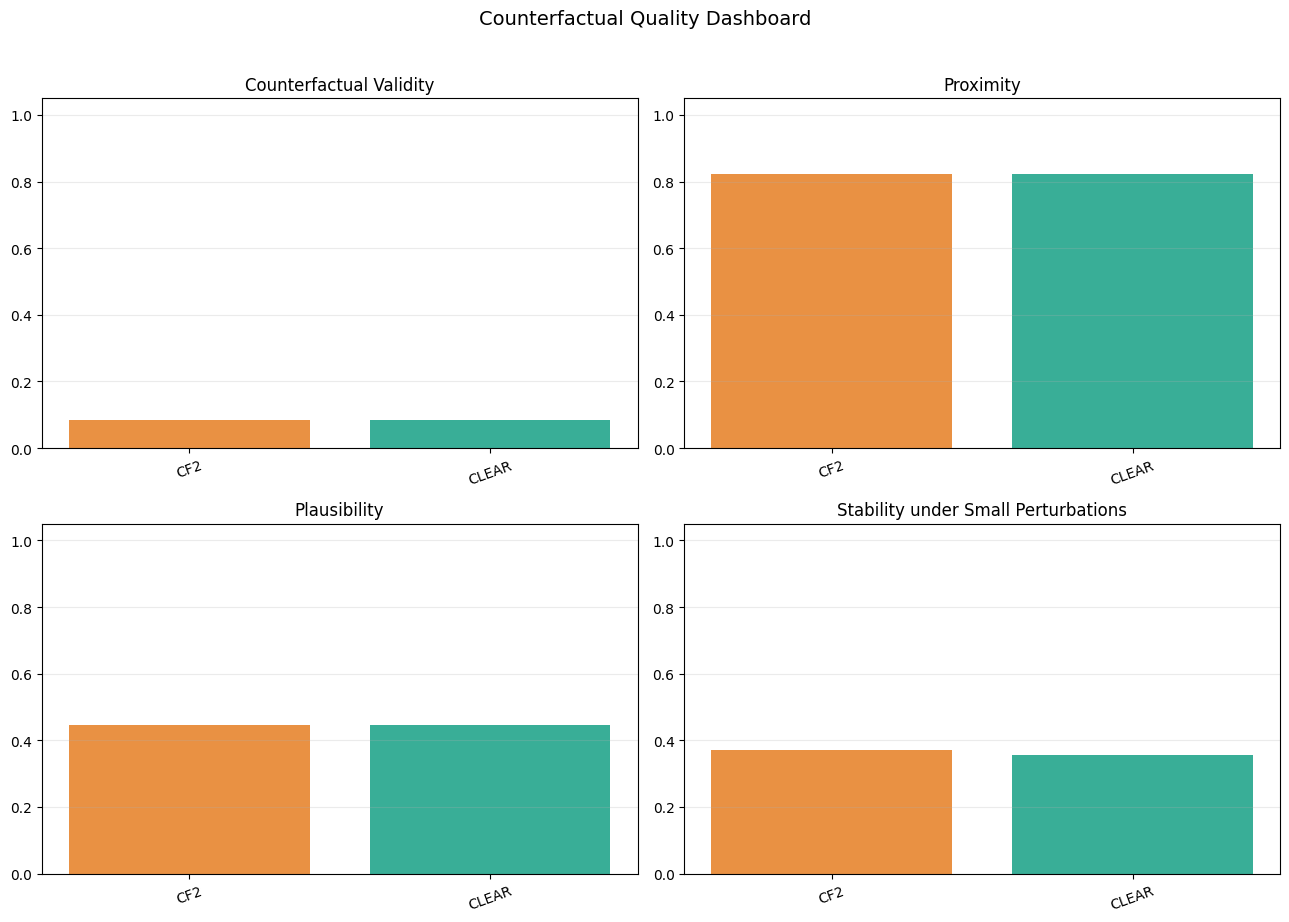

In [13]:
import time
import networkx as nx


def _cf_patient_inputs(patient_idx):
    return (
        C_test[patient_idx].clone(),
        T_test[patient_idx].clone(),
        L_test[patient_idx].clone(),
        PAD_MASK_test[patient_idx].clone(),
        DEMO_test[patient_idx].clone(),
    )


def _cf_prob_from_mask_tensors(c_seq, t_seq, l_seq, pad_mask, demo, edge_mask):
    c_m = c_seq.unsqueeze(0).to(DEVICE)
    t_m = t_seq.unsqueeze(0).to(DEVICE)
    l_m = l_seq.unsqueeze(0).to(DEVICE)
    pm_m = pad_mask.unsqueeze(0).to(DEVICE)
    dm_m = demo.unsqueeze(0).to(DEVICE)
    ei = EDGE_INDEX if edge_mask.sum() == 0 else EDGE_INDEX[:, edge_mask]
    return float(torch.sigmoid(model(ei, c_m, t_m, l_m, pm_m, dm_m)).item())


def _cf_plausibility(edge_mask):
    kept = np.flatnonzero(edge_mask)
    if len(kept) == 0:
        return 0.0

    g = nx.Graph()
    ei_np = EDGE_INDEX.detach().cpu().numpy()
    for eidx in kept:
        src_idx = int(ei_np[0, eidx])
        dst_idx = int(ei_np[1, eidx])
        src_c = idx2concept.get(src_idx)
        dst_c = idx2concept.get(dst_idx)
        if src_c is None or dst_c is None:
            continue
        g.add_edge(id2name.get(src_c, str(src_c)), id2name.get(dst_c, str(dst_c)))

    if g.number_of_nodes() < 2 or g.number_of_edges() == 0:
        return 0.0

    n_components = nx.number_connected_components(g)
    isolated = sum(1 for node in g.nodes if g.degree(node) == 0)
    component_score = 1.0 / max(n_components, 1)
    isolated_score = 1.0 - isolated / max(g.number_of_nodes(), 1)
    return float(np.clip(0.65 * component_score + 0.35 * isolated_score, 0.0, 1.0))


def _cf_importance_order(c_seq, t_seq, l_seq, pad_mask, demo):
    full_mask = np.ones(EDGE_INDEX.shape[1], dtype=bool)
    base_prob = _cf_prob_from_mask_tensors(c_seq, t_seq, l_seq, pad_mask, demo, full_mask)
    deltas = []
    for eidx in range(EDGE_INDEX.shape[1]):
        mask = full_mask.copy()
        mask[eidx] = False
        prob = _cf_prob_from_mask_tensors(c_seq, t_seq, l_seq, pad_mask, demo, mask)
        deltas.append(abs(base_prob - prob))
    return np.argsort(-np.asarray(deltas))


def cf2_counterfactual(c_seq, t_seq, l_seq, pad_mask, demo, max_remove=8):
    full_mask = np.ones(EDGE_INDEX.shape[1], dtype=bool)
    base_prob = _cf_prob_from_mask_tensors(c_seq, t_seq, l_seq, pad_mask, demo, full_mask)
    base_label = base_prob >= BEST_THR
    order = _cf_importance_order(c_seq, t_seq, l_seq, pad_mask, demo)

    current_mask = full_mask.copy()
    removed_edges = []
    current_prob = base_prob
    current_plaus = _cf_plausibility(current_mask)

    for _ in range(min(max_remove, EDGE_INDEX.shape[1])):
        best_state = None
        for eidx in order[:min(16, len(order))]:
            if not current_mask[eidx]:
                continue
            candidate_mask = current_mask.copy()
            candidate_mask[eidx] = False
            candidate_prob = _cf_prob_from_mask_tensors(c_seq, t_seq, l_seq, pad_mask, demo, candidate_mask)
            flipped = (candidate_prob >= BEST_THR) != base_label
            proximity = 1.0 - (len(removed_edges) + 1) / max(EDGE_INDEX.shape[1], 1)
            plausibility = _cf_plausibility(candidate_mask)
            score = 3.0 * float(flipped) + 1.2 * proximity + 0.8 * plausibility - abs(candidate_prob - BEST_THR)
            if best_state is None or score > best_state[0]:
                best_state = (score, candidate_mask, candidate_prob, eidx, plausibility, flipped)

        if best_state is None:
            break

        _, current_mask, current_prob, chosen_edge, current_plaus, flipped = best_state
        removed_edges.append(int(chosen_edge))
        if flipped:
            break

    return {
        "base_prob": base_prob,
        "cf_prob": current_prob,
        "removed_edges": removed_edges,
        "kept_mask": current_mask,
        "valid": bool((base_prob >= BEST_THR) != (current_prob >= BEST_THR)),
        "proximity": 1.0 - (len(removed_edges) / max(EDGE_INDEX.shape[1], 1)),
        "sparsity": len(removed_edges) / max(EDGE_INDEX.shape[1], 1),
        "plausibility": current_plaus,
    }


def clear_counterfactual(c_seq, t_seq, l_seq, pad_mask, demo, max_remove=8, beam_size=4, branch_factor=5):
    full_mask = np.ones(EDGE_INDEX.shape[1], dtype=bool)
    base_prob = _cf_prob_from_mask_tensors(c_seq, t_seq, l_seq, pad_mask, demo, full_mask)
    base_label = base_prob >= BEST_THR
    order = _cf_importance_order(c_seq, t_seq, l_seq, pad_mask, demo)

    beam = [{
        "mask": full_mask,
        "removed": [],
        "prob": base_prob,
        "plausibility": _cf_plausibility(full_mask),
        "score": 0.0,
    }]
    best_valid = None

    for _ in range(min(max_remove, EDGE_INDEX.shape[1])):
        candidates = []
        for state in beam:
            available = [eidx for eidx in order if state["mask"][eidx]][:branch_factor]
            for eidx in available:
                candidate_mask = state["mask"].copy()
                candidate_mask[eidx] = False
                candidate_prob = _cf_prob_from_mask_tensors(c_seq, t_seq, l_seq, pad_mask, demo, candidate_mask)
                flipped = (candidate_prob >= BEST_THR) != base_label
                proximity = 1.0 - (len(state["removed"]) + 1) / max(EDGE_INDEX.shape[1], 1)
                plausibility = _cf_plausibility(candidate_mask)
                score = 2.8 * float(flipped) + 1.0 * proximity + 1.1 * plausibility - 0.05 * len(state["removed"]) - abs(candidate_prob - BEST_THR)
                candidates.append({
                    "mask": candidate_mask,
                    "removed": state["removed"] + [int(eidx)],
                    "prob": candidate_prob,
                    "plausibility": plausibility,
                    "score": score,
                    "flipped": flipped,
                })

        if not candidates:
            break

        candidates.sort(key=lambda item: (item["score"], item["flipped"], -len(item["removed"])), reverse=True)
        beam = candidates[:beam_size]
        valid_now = [item for item in beam if item["flipped"]]
        if valid_now:
            valid_now.sort(key=lambda item: (item["score"], -len(item["removed"])), reverse=True)
            best_valid = valid_now[0]
            break

    if best_valid is None:
        best_valid = beam[0]

    return {
        "base_prob": base_prob,
        "cf_prob": best_valid["prob"],
        "removed_edges": best_valid["removed"],
        "kept_mask": best_valid["mask"],
        "valid": bool((base_prob >= BEST_THR) != (best_valid["prob"] >= BEST_THR)),
        "proximity": 1.0 - (len(best_valid["removed"]) / max(EDGE_INDEX.shape[1], 1)),
        "sparsity": len(best_valid["removed"]) / max(EDGE_INDEX.shape[1], 1),
        "plausibility": best_valid["plausibility"],
    }


def _perturb_counterfactual_inputs(c_seq, t_seq, l_seq, pad_mask, demo, rng, drop_count=1):
    c_pert = c_seq.clone()
    t_pert = t_seq.clone()
    l_pert = l_seq.clone()
    pm_pert = pad_mask.clone()
    dm_pert = demo.clone()

    valid_positions = torch.where(~pm_pert)[0].cpu().numpy()
    if len(valid_positions) == 0:
        return c_pert, t_pert, l_pert, pm_pert, dm_pert

    n_drop = min(drop_count, len(valid_positions))
    drop_positions = rng.choice(valid_positions, size=n_drop, replace=False)
    for pos in drop_positions:
        c_pert[pos] = PAD_IDX
        pm_pert[pos] = True

    return c_pert, t_pert, l_pert, pm_pert, dm_pert


def _cf_metrics_for_method(method_fn, patient_indices, n_perturb=3):
    rows = []
    stab_rows = []
    for pi in patient_indices:
        c_seq, t_seq, l_seq, pm_seq, dm_seq = _cf_patient_inputs(pi)
        result = method_fn(c_seq, t_seq, l_seq, pm_seq, dm_seq)
        if result is None:
            continue

        rows.append({
            "patient_idx": int(pi),
            "valid": int(result["valid"]),
            "proximity": float(result["proximity"]),
            "sparsity": float(result["sparsity"]),
            "plausibility": float(result["plausibility"]),
            "flip_gap": abs(float(result["cf_prob"]) - float(result["base_prob"])),
        })

        base_removed = set(result["removed_edges"])
        if len(base_removed) == 0:
            continue

        rng = np.random.RandomState(1000 + int(pi))
        jaccards = []
        for _ in range(n_perturb):
            c_p, t_p, l_p, pm_p, dm_p = _perturb_counterfactual_inputs(c_seq, t_seq, l_seq, pm_seq, dm_seq, rng, drop_count=1)
            pert_result = method_fn(c_p, t_p, l_p, pm_p, dm_p)
            if pert_result is None:
                continue
            pert_removed = set(pert_result["removed_edges"])
            union = len(base_removed | pert_removed)
            if union == 0:
                continue
            jaccards.append(len(base_removed & pert_removed) / union)

        if jaccards:
            stab_rows.append({"patient_idx": int(pi), "stability": float(np.mean(jaccards))})

    metric_df = pd.DataFrame(rows)
    stab_df = pd.DataFrame(stab_rows)
    return metric_df, stab_df


cf_eval_indices = np.concatenate([true_pos_idx[:6], true_neg_idx[:6]])
np.random.seed(42)
np.random.shuffle(cf_eval_indices)

cf_methods = {
    "CF2": cf2_counterfactual,
    "CLEAR": clear_counterfactual,
}

print("Computing counterfactual metrics...")
cf_metric_results = {}
cf_stability_results = {}
for name, fn in cf_methods.items():
    print(f"  {name}...")
    metric_df, stab_df = _cf_metrics_for_method(fn, cf_eval_indices, n_perturb=3)
    cf_metric_results[name] = metric_df
    cf_stability_results[name] = stab_df

cf_summary_rows = []
for name in cf_methods:
    metric_df = cf_metric_results[name]
    stab_df = cf_stability_results[name]
    cf_summary_rows.append({
        "Method": name,
        "Validity": metric_df["valid"].mean() if len(metric_df) else np.nan,
        "Proximity": metric_df["proximity"].mean() if len(metric_df) else np.nan,
        "Sparsity": metric_df["sparsity"].mean() if len(metric_df) else np.nan,
        "Plausibility": metric_df["plausibility"].mean() if len(metric_df) else np.nan,
        "Perturbation Stability": stab_df["stability"].mean() if len(stab_df) else np.nan,
        "n_eval": len(metric_df),
    })

cf_summary_df = pd.DataFrame(cf_summary_rows).set_index("Method")
print("\nCounterfactual Evaluation Summary:")
print(cf_summary_df.to_string(float_format=lambda x: f"{x:.3f}"))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
plot_cols = ["Validity", "Proximity", "Plausibility", "Perturbation Stability"]
plot_titles = ["Counterfactual Validity", "Proximity", "Plausibility", "Stability under Small Perturbations"]
for ax, col, title in zip(axes.flat, plot_cols, plot_titles):
    vals = cf_summary_df[col]
    ax.bar(vals.index, vals.values, color=["#e67e22", "#16a085"][:len(vals)], alpha=0.85)
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.25, axis="y")
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Counterfactual Quality Dashboard", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(PLOTS / "counterfactual_quality_dashboard.png", dpi=220, bbox_inches="tight")
plt.show()

## 8. Comparison Dashboard

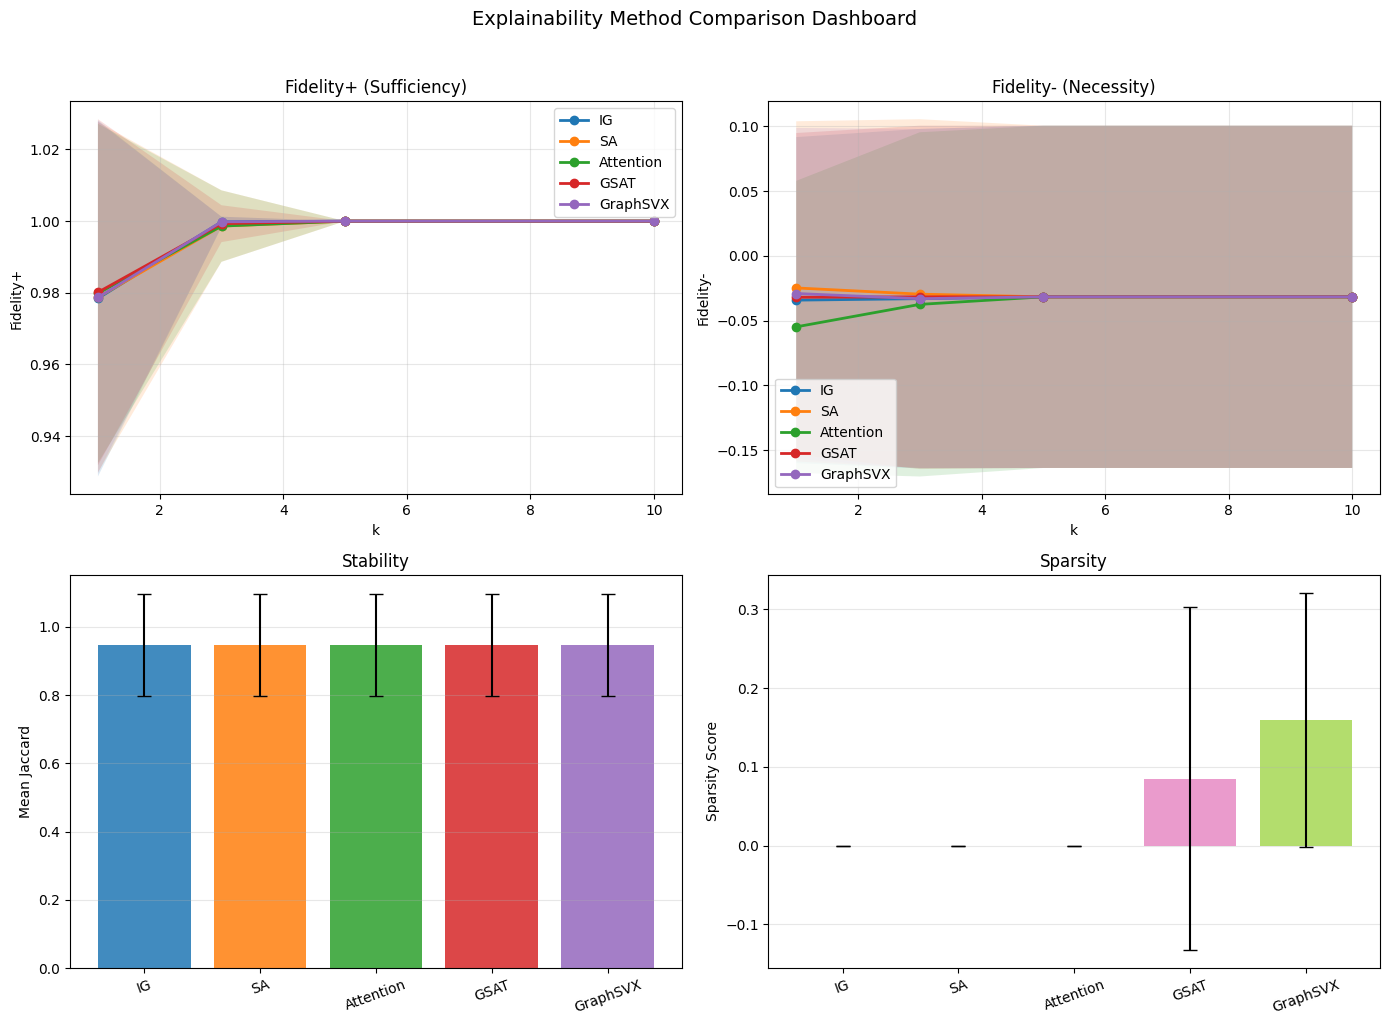

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
for name in METHODS:
    df = fid_plus_results[name]
    ax.plot(df["k"], df["mean_fidelity+"], "o-", label=name, lw=2)
    ax.fill_between(df["k"], df["mean_fidelity+"] - df["std"],
                     df["mean_fidelity+"] + df["std"], alpha=0.15)
ax.set_xlabel("k"); ax.set_ylabel("Fidelity+")
ax.set_title("Fidelity+ (Sufficiency)")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
for name in METHODS:
    df = fid_minus_results[name]
    ax.plot(df["k"], df["mean_fidelity-"], "o-", label=name, lw=2)
    ax.fill_between(df["k"], df["mean_fidelity-"] - df["std"],
                     df["mean_fidelity-"] + df["std"], alpha=0.15)
ax.set_xlabel("k"); ax.set_ylabel("Fidelity-")
ax.set_title("Fidelity- (Necessity)")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 0]
methods_list = list(stability_results.keys())
means = [stability_results[m]["mean_jaccard"] for m in methods_list]
stds  = [stability_results[m]["std_jaccard"] for m in methods_list]
colors = sns.color_palette("tab10", n_colors=max(3, len(methods_list)))
ax.bar(methods_list, means, yerr=stds, color=colors[:len(methods_list)], capsize=5, alpha=0.85)
ax.set_ylabel("Mean Jaccard"); ax.set_title("Stability"); ax.grid(alpha=0.3, axis="y")
ax.tick_params(axis="x", rotation=20)

ax = axes[1, 1]
methods_list_s = list(sparsity_results.keys())
means_s = [sparsity_results[m]["mean_sparsity"] for m in methods_list_s]
stds_s  = [sparsity_results[m]["std_sparsity"]  for m in methods_list_s]
colors_s = sns.color_palette("Set2", n_colors=max(3, len(methods_list_s)))
ax.bar(methods_list_s, means_s, yerr=stds_s, color=colors_s[:len(methods_list_s)], capsize=5, alpha=0.85)
ax.set_ylabel("Sparsity Score"); ax.set_title("Sparsity"); ax.grid(alpha=0.3, axis="y")
ax.tick_params(axis="x", rotation=20)

plt.suptitle("Explainability Method Comparison Dashboard", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(PLOTS / "evaluation_dashboard.png", dpi=220, bbox_inches="tight")
plt.show()

## 9. Summary Table

In [11]:
summary_rows = []
for name in METHODS:
    fp = fid_plus_results[name]
    fm = fid_minus_results[name]
    row = {
        "Method":             name,
        "Fidelity+ (k=3)":   fp[fp["k"]==3]["mean_fidelity+"].values[0]
                              if 3 in fp["k"].values else np.nan,
        "Fidelity− (k=3)":   fm[fm["k"]==3]["mean_fidelity-"].values[0]
                              if 3 in fm["k"].values else np.nan,
        "Stability (Jaccard)": stability_results[name]["mean_jaccard"],
        "Sparsity":            sparsity_results[name]["mean_sparsity"],
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("Method")
print("=" * 70)
print("EXPLAINABILITY EVALUATION SUMMARY")
print("=" * 70)
print(summary_df.to_string(float_format="%.3f"))

EXPLAINABILITY EVALUATION SUMMARY
           Fidelity+ (k=3)  Fidelity− (k=3)  Stability (Jaccard)  Sparsity
Method                                                                    
IG                   1.000           -0.033                0.948     0.000
SA                   0.999           -0.030                0.948     0.000
Attention            0.999           -0.037                0.948     0.000
GSAT                 0.999           -0.032                0.948     0.085
GraphSVX             1.000           -0.033                0.948     0.160


## 10. Method Resume

### How to read the results
- **Fidelity+**: higher means the selected evidence preserves the original prediction.
- **Fidelity−**: higher magnitude means removing the evidence changes the prediction more.
- **Stability**: higher means explanations stay similar under nearest-neighbor comparison.
- **Sparsity**: higher means fewer features are needed for a compact explanation.
- **Counterfactual validity**: higher means the edit actually flips the model decision.
- **Proximity / sparsity**: lower edit size is better for counterfactuals.
- **Plausibility**: higher means the counterfactual remains structurally reasonable.
- **Perturbation stability**: higher means the counterfactual survives small input changes.